In [280]:
import numpy as np
import sympy as sym
import matplotlib.pyplot as plt
from IPython.display import display

In [281]:
# Define 'x' and 'y' variables
x = sym.symbols('x')
y = sym.symbols('y')

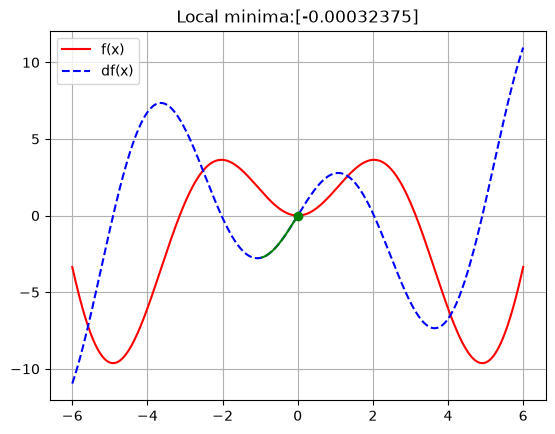

In [282]:
# Experiment 1: Implement a Gradient Descent algorithm for a 1-dimensional array
space_x = np.linspace(-6, 6, 500)

fx1 = sym.sin(x) * 2 * x
df1 = sym.diff(fx1, x)

fx1_func = sym.lambdify(x, fx1)
df1_func = sym.lambdify(x, df1)

localmin = np.random.uniform(space_x[0], space_x[-1], 1)
training_epochs = 200
learning_rate = 0.01
records = np.zeros((training_epochs, 2))

for i in range(training_epochs):
    grad = df1_func(localmin)
    records[i] = localmin[0], grad[0]
    localmin = localmin - grad * learning_rate

plt.plot(space_x, fx1_func(space_x), 'r-')
plt.plot(space_x, df1_func(space_x), 'b--')
plt.plot(records[:,0], records[:,1], 'g-')
plt.plot(records[-1][0], records[-1][1], 'go')
plt.legend(['f(x)', 'df(x)'])
plt.title('Local minima:' + str(localmin))
plt.grid()
plt.show()

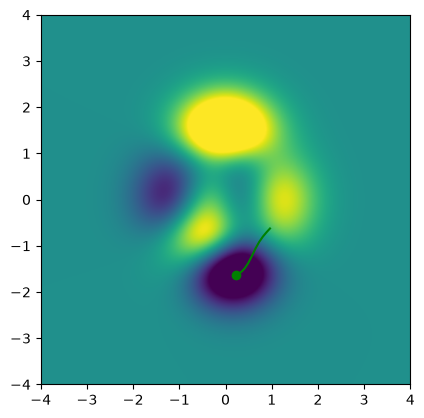

In [283]:
# Experiment 2: Implement a Gradient Descent algorithm for a 2-dimensional array

space_x = np.linspace(-4, 4, 500)

fx2 = 3*(1-x)**2 * sym.exp(-(x**2) - (y+1)**2) - 10 * (x/5 - x**3 - y**5) * sym.exp(-x**2 - y**2) - 1/3 * sym.exp(-(x+1)**2 - y**2)
df2_x = sym.diff(fx2, x)
df2_y = sym.diff(fx2, y)

fx2_func = sym.lambdify((x, y), fx2)
df2_x_func = sym.lambdify((x, y), df2_x)
df2_y_func = sym.lambdify((x,y), df2_y)

x_val, y_val = np.meshgrid(space_x, space_x)
z_val = fx2_func(x_val, y_val)

localmin = np.random.uniform(space_x[0], space_x[-1], 2)
training_epochs = 200
learning_rate = 0.02
records = np.zeros((training_epochs, 2))

for i in range(training_epochs):
    grad = np.array([
        df2_x_func(localmin[0], localmin[1]),
        df2_y_func(localmin[0], localmin[1])
    ])
    records[i] = localmin[0], localmin[1]
    localmin = localmin - grad * learning_rate

plt.imshow(z_val, extent=[space_x[0], space_x[-1], space_x[0], space_x[-1]], vmin=space_x[0], vmax=space_x[-1], origin='lower')
plt.plot(records[:,0], records[:,1], 'g-')
plt.plot(records[-1][0], records[-1][1], 'go')
plt.show()


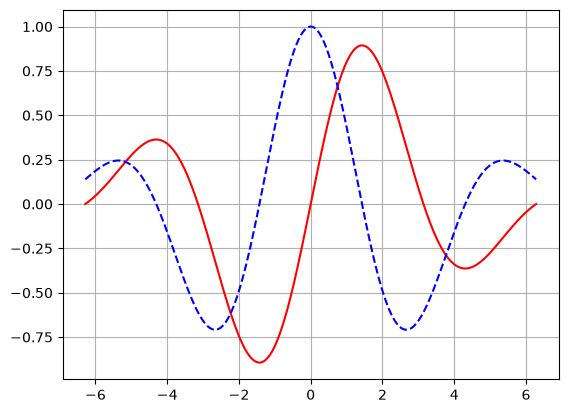

In [284]:
# Experiment 3: Parametric experiments

space_x = np.linspace(-2*np.pi, 2*np.pi, 500)

fx3 = sym.sin(x) * sym.exp(-x**2*0.05)
fx3_func = sym.lambdify(x, fx3)

df3 = sym.diff(fx3, x)
df3_func = sym.lambdify(x, df3)

plt.plot(space_x, fx3_func(space_x), 'r-')
plt.plot(space_x, df3_func(space_x), 'b--')
plt.grid()
plt.show()

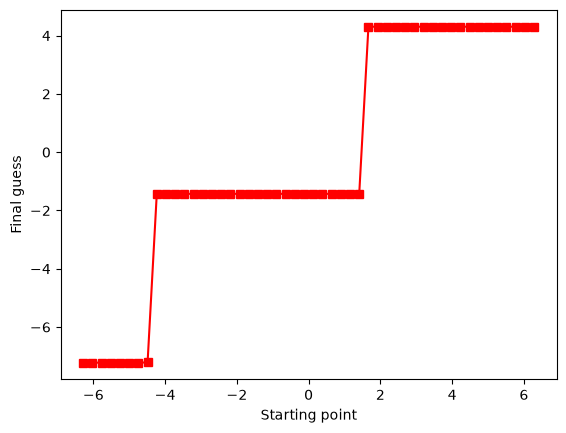

In [285]:
# Experiment 3.1: Varying the starting point

start_locs = np.linspace(space_x[0], space_x[-1], 50)
end_locs = np.zeros(len(start_locs))

training_epochs = 500
learning_rate = 0.1

for idx, localmin in enumerate(start_locs):
    for i in range(training_epochs):
        grad = df3_func(localmin)
        localmin = localmin - grad * learning_rate
    end_locs[idx] = localmin

plt.plot(start_locs, end_locs, 'rs-')
plt.xlabel('Starting point')
plt.ylabel('Final guess')
plt.show()


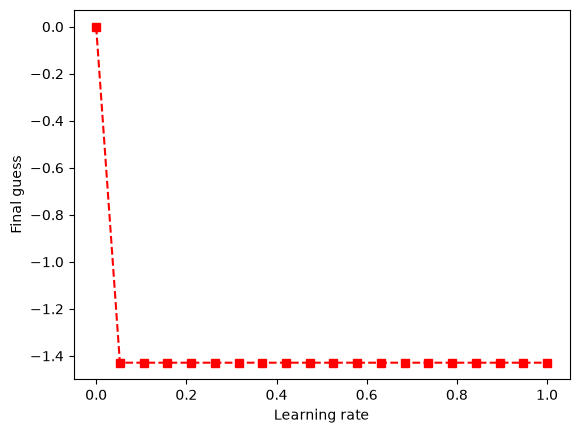

In [286]:
# Experiment 3.2: Varying the learning rate

rates = np.linspace(0, 1, 20)
end_locs = np.zeros(len(rates))

training_epochs = 500
start_loc = 0.0

for idx, learning_rate in enumerate(rates):
    localmin = start_loc
    for i in range(training_epochs):
        grad = df3_func(localmin)
        localmin = localmin - grad * learning_rate
    end_locs[idx] = localmin

plt.plot(rates, end_locs, 'rs--')
plt.xlabel('Learning rate')
plt.ylabel('Final guess')
plt.show()

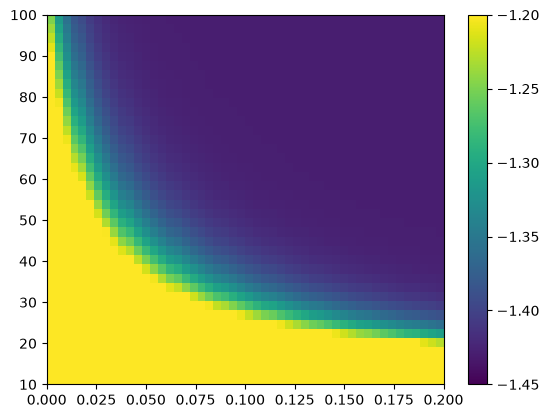

In [287]:
# Experiment 3.3: Varying learning rate and training epochs

rates = np.linspace(0, 0.2, 40)
epochs = np.round(np.linspace(10, 100, 50))
end_locs = np.zeros((len(rates), len(epochs)))

start_loc = 0.0

for ridx, learning_rate in enumerate(rates):
    for eidx, training_epochs in enumerate(epochs):
        localmin = start_loc
        for i in range(int(training_epochs)):
            grad = df3_func(localmin)
            localmin = localmin - grad * learning_rate
        end_locs[ridx][eidx] = localmin

plt.imshow(end_locs, extent=[rates[0], rates[-1], epochs[0], epochs[-1]], aspect='auto', origin='lower', vmin=-1.45, vmax=-1.2)
plt.colorbar()
        

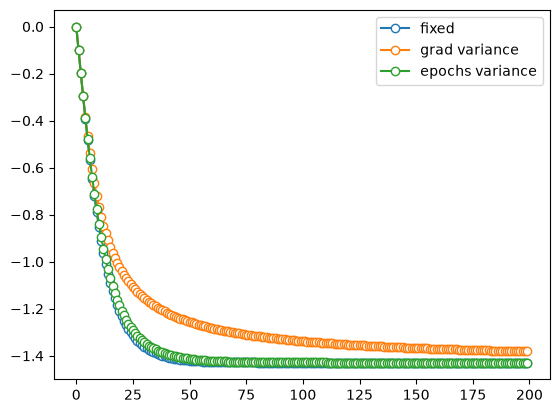

In [288]:
# Experiment 4: Dynamic learning rate

training_epochs = 200
learning_rate = 0.1
start_loc = 0.0

localmin = start_loc
results_fixed = np.zeros(training_epochs)
for i in range(training_epochs):
    grad = df3_func(localmin)
    results_fixed[i] = localmin
    localmin = localmin - grad * learning_rate

localmin = start_loc
results_grad_variance = np.zeros(training_epochs)
for i in range(training_epochs):
    grad = df3_func(localmin)
    results_grad_variance[i] = localmin
    lr = learning_rate * abs(grad)
    localmin = localmin - grad * lr

localmin = start_loc
results_epoch_variance = np.zeros(training_epochs)
for i in range(training_epochs):
    grad = df3_func(localmin)
    results_epoch_variance[i] = localmin
    lr = learning_rate * (1 - i/training_epochs)
    localmin = localmin - grad * lr

x_val = np.arange(0, training_epochs)
plt.plot(x_val, results_fixed, "o-", markerfacecolor='w')
plt.plot(x_val, results_grad_variance, "o-", markerfacecolor='w')
plt.plot(x_val, results_epoch_variance, "o-", markerfacecolor='w')
plt.legend(['fixed', 'grad variance', 'epochs variance'])
plt.show()